In [1]:
import os
import numpy as np
import scvelo as scv
import scanpy as sc
import pandas as pd
import topovelo as tpv
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = ''
DATA_NAME = 'slide-seq-adult-cortex'

In [3]:
adata = sc.read(os.path.join(DATA_DIR, f'{DATA_NAME}_pp.h5ad'))

In [4]:
FIG_DIR='./figures'
MODEL_DIR = './checkpoints'
DATA_DIR = ''

# (Optional) Build a spatial graph
We have already calculated a spatial graph using Delaunay triangulation for this dataset. Please run the following code block if you want to switch to other types of graphs.

In [7]:
tpv.build_spatial_graph(
    adata,
    'X_spatial',
    method='BallTree',
    radius=30
)

Ball Tree: average number of neighbors: 10.1


# GCN

In [6]:
figure_path = f'{FIG_DIR}/gcn'
model_path = f'{MODEL_DIR}/gcn'

vae = tpv.VAE(adata, 
              tmax=20, 
              dim_z=5, 
              hidden_size=(50, 25, 50),
              device='cuda:0',
              graph_decoder=True,
              attention=False)
config = {
    
}
vae.train(adata,
          adata.obsp['spatial_graph'],
          "X_spatial",
          config=config,
          embed='spatial'
)
vae.save_model(model_path, 'encoder', 'decoder')
vae.save_anndata(adata, 'gcn', DATA_DIR, file_name="adata_out.h5ad")

Estimating ODE parameters...


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Reinitialize the regular ODE parameters based on estimated global latent time.


  0%|          | 0/200 [00:00<?, ?it/s]

*********               Creating a Graph Dataset              *********
*********                      Finished.                      *********
--------------------------- Train a TopoVelo ---------------------------
*********                 Creating optimizers                 *********
*********                      Finished.                      *********
*********                    Start training                   *********
*********                      Stage  1                       *********
*********       Stage 1: Early Stop Triggered at epoch 201.       *********
Summary: 
Train ELBO = 328.623
Test ELBO = 333.972
Total Time =   0 h :  0 m : 41 s

*********                      Stage  2                       *********


Calculating KNN:   0%|          | 0/2525 [00:00<?, ?it/s]

Stage 2: Early Stop Triggered at round 4.
Final: Train ELBO = 502.154,	Test ELBO = 504.391
*********              Finished. Total Time =   0 h :  1 m : 18 s             *********


## Graph Attention

In [7]:
figure_path = f'{FIG_DIR}/gat'
model_path = f'{MODEL_DIR}/gat'

vae = tpv.VAE(adata, 
              tmax=20, 
              dim_z=5, 
              hidden_size=(50, 25, 50),
              device='cuda:0',
              graph_decoder=True,
              attention=True,
              reverse_gene_mode=True)
config = {
    
}
vae.train(adata,
          adata.obsp['spatial_graph'],
          "X_spatial",
          config=config,
          plot=False,
          embed='spatial')
vae.save_model(model_path, 'encoder', 'decoder')
vae.save_anndata(adata, 'gat', DATA_DIR, file_name="adata_out.h5ad")

Estimating ODE parameters...


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Reinitialize the regular ODE parameters based on estimated global latent time.


  0%|          | 0/200 [00:00<?, ?it/s]

*********               Creating a Graph Dataset              *********
*********                      Finished.                      *********
--------------------------- Train a TopoVelo ---------------------------
*********                 Creating optimizers                 *********
*********                      Finished.                      *********
*********                    Start training                   *********
*********                      Stage  1                       *********
*********       Stage 1: Early Stop Triggered at epoch 244.       *********
Summary: 
Train ELBO = 340.834
Test ELBO = 336.558
Total Time =   0 h :  1 m : 41 s

*********                      Stage  2                       *********


Calculating KNN:   0%|          | 0/2525 [00:00<?, ?it/s]

Stage 2: Early Stop Triggered at round 4.
Final: Train ELBO = 509.373,	Test ELBO = 512.967
*********              Finished. Total Time =   0 h :  2 m : 10 s             *********


---   Plotting  Results   ---
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/32 cores)


  0%|          | 0/2525 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'gcn_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gcn_velocity_spatial', embedded velocity vectors (adata.obsm)


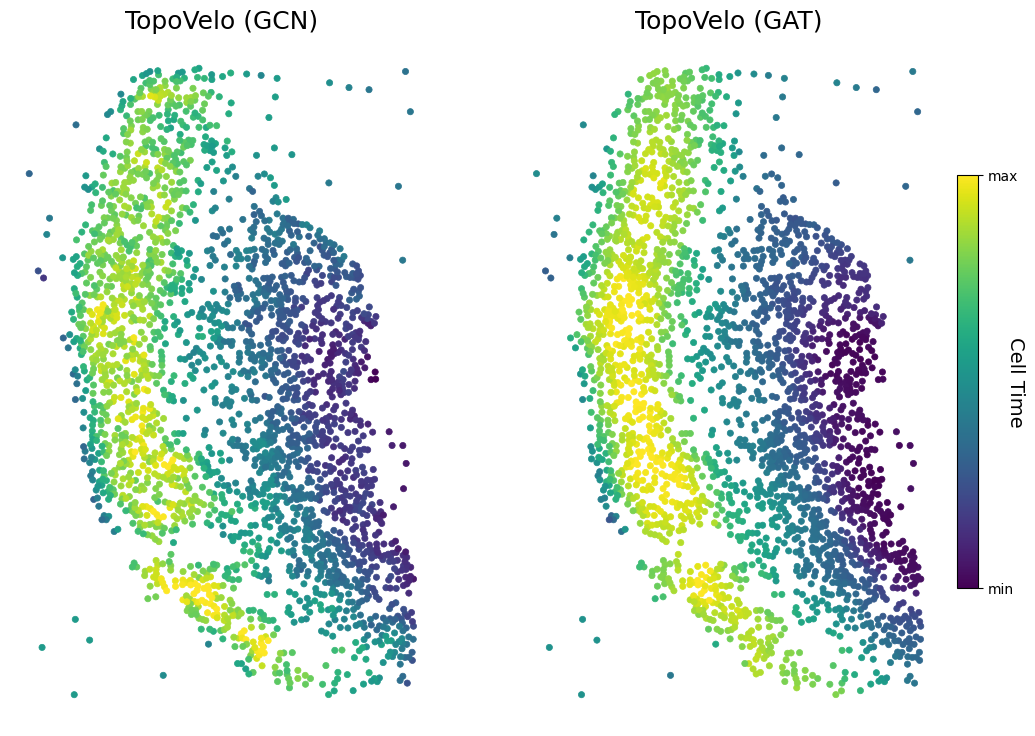

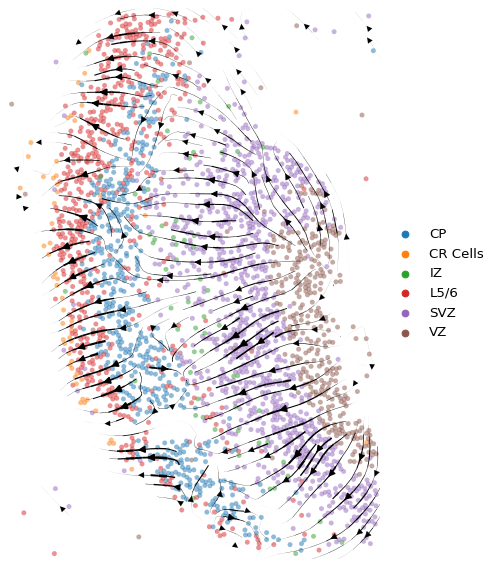

Recovering the original KNN graph from .uns
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/32 cores)


  0%|          | 0/2525 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_spatial', embedded velocity vectors (adata.obsm)


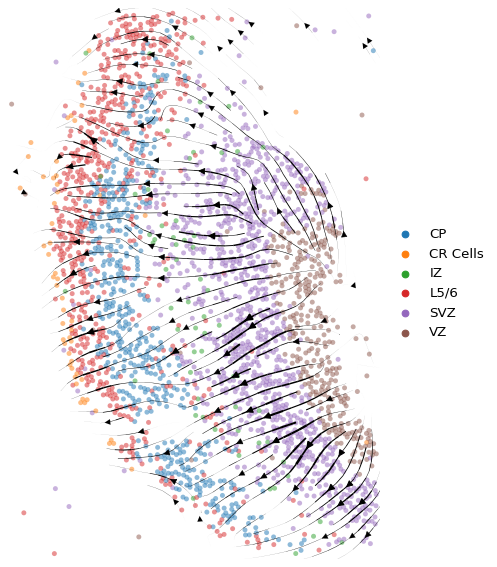

Recovering the original KNN graph from .uns


In [8]:
_ = tpv.post_analysis(
    adata,
    DATA_NAME,
    ['TopoVelo (GCN)', 'TopoVelo (GAT)'],
    ['gcn', 'gat'],
    plot_type=['cell velocity', 'time']
)